In [ ]:
include("parisiSolvers.jl")
using Plots
using Optim
using ADTypes: AutoForwardDiff
import ForwardDiff
using Plots.PlotMeasures

### Description

Instead of optimizing directly over the coefficients of the piecewise constant function $\gamma_K(t)$, we optimize over an intermediate 
    parametrization of $\gamma_K(t)$, which automatically enforces monotonicity and boundedness.
Specifically, we use the following parametrizations:

$$g_k = \sum_{i=1}^k \log\!\left(1 + e^{\theta_i}\right)$$


$$g_k = \sum_{i=1}^k \frac{e^{\theta_i}}{\sum_{j=1}^K e^{\theta_j}}$$

Both enforce monotonicity and nonnegativity, and the second also enforces an upper bound of 1.

In [2]:
K = 50
tgrid = collect(range(0.0, 1.0, length=K+1));

theta0 = log.(fill(0.05, K))  
g0 = softplus(theta0);

### Pure spin, $p=3$

In [3]:
objective_p3 = make_objective(tgrid; p=3, L=8.0, Nx=1001, Q=40)
@time res_p3 = optimize(objective_p3, theta0, LBFGS(); autodiff=AutoForwardDiff()) 


2259.718225 seconds (38.92 M allocations: 870.941 GiB, 6.23% gc time, 0.27% compilation time: <1% of which was recompilation)


 * Status: success

 * Candidate solution
    Final objective value:     1.150621e+00

 * Found with
    Algorithm:     L-BFGS

 * Convergence measures
    |x - x'|               = 1.10e+01 ≰ 0.0e+00
    |x - x'|/|x'|          = 1.70e-02 ≰ 0.0e+00
    |f(x) - f(x')|         = 2.05e-12 ≰ 0.0e+00
    |f(x) - f(x')|/|f(x')| = 1.78e-12 ≰ 0.0e+00
    |g(x)|                 = 7.76e-09 ≤ 1.0e-08

 * Work counters
    Seconds run:   2254  (vs limit Inf)
    Iterations:    258
    f(x) calls:    341
    ∇f(x) calls:   341
    ∇f(x)ᵀv calls: 0


In [4]:
theta_star_p3 = Optim.minimizer(res_p3)
g_star_p3 = softplus(theta_star_p3)

println("Optimized P(gamma) (p=3) = ", objective_p3(theta_star_p3))

Optimized P(gamma) (p=3) = 1.1506213530926495


### Pure spin, $p=2$

In [5]:
objective_p2 = make_objective(tgrid; p=2, L=8.0, Nx=1001, Q=40)
@time res_p2 = optimize(objective_p2, theta0, LBFGS(); autodiff=AutoForwardDiff()) 

156.365410 seconds (3.41 M allocations: 461.460 GiB, 43.20% gc time)


 * Status: success

 * Candidate solution
    Final objective value:     1.079833e+00

 * Found with
    Algorithm:     L-BFGS

 * Convergence measures
    |x - x'|               = 2.89e-03 ≰ 0.0e+00
    |x - x'|/|x'|          = 7.01e-04 ≰ 0.0e+00
    |f(x) - f(x')|         = 6.99e-12 ≰ 0.0e+00
    |f(x) - f(x')|/|f(x')| = 6.47e-12 ≰ 0.0e+00
    |g(x)|                 = 6.37e-09 ≤ 1.0e-08

 * Work counters
    Seconds run:   155  (vs limit Inf)
    Iterations:    159
    f(x) calls:    181
    ∇f(x) calls:   181
    ∇f(x)ᵀv calls: 0


In [6]:
theta_star_p2 = Optim.minimizer(res_p2)
g_star_p2 = softplus(theta_star_p2)

println("Optimized P(gamma) (p=2) = ", objective_p2(theta_star_p2))

Optimized P(gamma) (p=2) = 1.0798326465316808


### Pure spin, $p=4$

In [7]:
objective_p4 = make_objective(tgrid; p=4, L=8.0, Nx=1001, Q=40)
@time res_p4 = optimize(objective_p4, theta0, LBFGS(); autodiff=AutoForwardDiff()) 

1197.338382 seconds (26.34 M allocations: 3.478 TiB, 43.51% gc time)


 * Status: success

 * Candidate solution
    Final objective value:     1.168052e+00

 * Found with
    Algorithm:     L-BFGS

 * Convergence measures
    |x - x'|               = 6.30e+04 ≰ 0.0e+00
    |x - x'|/|x'|          = 2.67e-02 ≰ 0.0e+00
    |f(x) - f(x')|         = 2.89e-15 ≰ 0.0e+00
    |f(x) - f(x')|/|f(x')| = 2.47e-15 ≰ 0.0e+00
    |g(x)|                 = 7.85e-10 ≤ 1.0e-08

 * Work counters
    Seconds run:   1197  (vs limit Inf)
    Iterations:    883
    f(x) calls:    1397
    ∇f(x) calls:   1397
    ∇f(x)ᵀv calls: 0


In [8]:
theta_star_p4 = Optim.minimizer(res_p4)
g_star_p4 = softplus(theta_star_p4)

println("Optimized P(gamma) (p=4) = ", objective_p4(theta_star_p4))

Optimized P(gamma) (p=4) = 1.1680522124910477


### Plots

A priori we expect $p=3$ to have  $p=2$ to not be flat. For $p=3$ we don't really know, but expect flatness. For $p=4$ we expect flatness. 

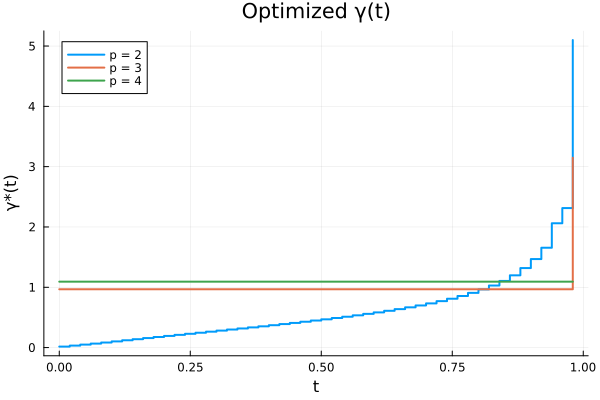

In [9]:
plot(
    tgrid[1:end-1],
    g_star_p2,
    seriestype=:steppost,
    xlabel="t",
    ylabel="γ*(t)",
    linewidth=2,
    label="p = 2",
    title = "Optimized γ(t)",
)

plot!(
    tgrid[1:end-1],
    g_star_p3,
    seriestype=:steppost,
    xlabel="t",
    ylabel="γ*(t)",
    linewidth=2,
    label="p = 3"
)


plot!(
    tgrid[1:end-1],
    g_star_p4,
    seriestype=:steppost,
    xlabel="t",
    ylabel="γ*(t)",
    linewidth=2,
    label="p = 4"
)

### $K = 2, 3, 4, 5, 6, 7$

In [32]:
p_vals = 2:7
K = 20
theta_map = softplus


tgrid = collect(range(0.0, 1.0, length=K+1));

lower = zeros(K)
upper = ones(K)

theta0 = log.(fill(0.05, K))  
g0 = theta_map(theta0);

g_stars_softplus = Dict{Int, Vector{Float64}}()

for p in p_vals
    objective = make_objective(tgrid; p=p, L=8.0, Nx=1001, Q=40, theta_to_g=theta_map)
    @time res = optimize(objective, theta0, LBFGS(); autodiff=AutoForwardDiff()) 
    theta_star = Optim.minimizer(res)
    g_star = theta_map(theta_star)
    g_stars_softplus[p] = g_star
end 


 28.562191 seconds (513.01 k allocations: 64.296 GiB, 42.69% gc time)
 21.291314 seconds (435.62 k allocations: 54.591 GiB, 39.54% gc time)
 51.606393 seconds (1.11 M allocations: 139.107 GiB, 40.42% gc time)
140.989542 seconds (3.08 M allocations: 386.182 GiB, 40.45% gc time)
217.024248 seconds (4.74 M allocations: 594.033 GiB, 40.55% gc time)
184.443699 seconds (4.04 M allocations: 506.283 GiB, 40.56% gc time)


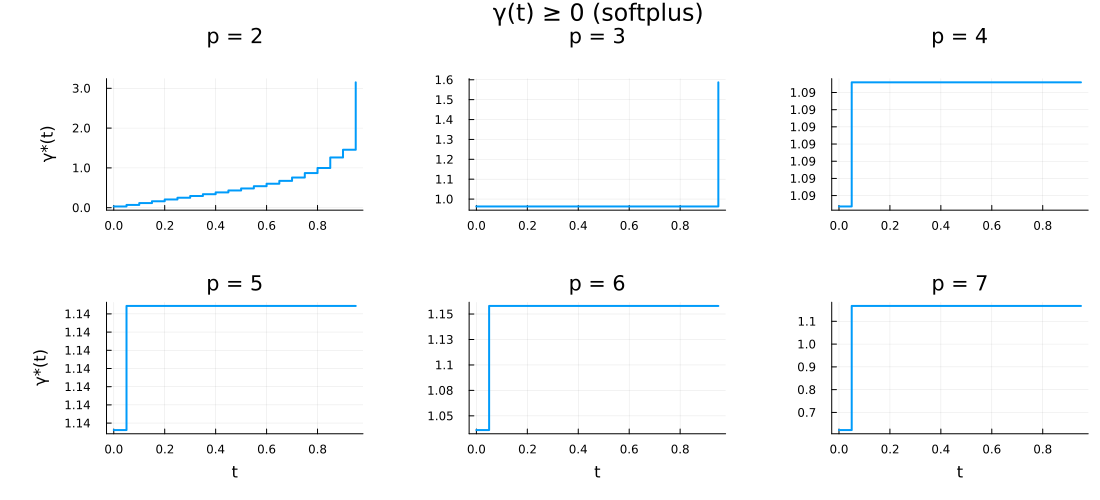

In [33]:
subplots = [
    plot(tgrid[1:end-1], g_stars_softplus[p],
        seriestype = :steppost, linewidth = 2,
        title = "p = $p",
        xlabel = p >= 5 ? "t" : "",
        ylabel = p in (2, 5) ? "γ*(t)" : "",
        legend = false,
        yformatter = x -> string(round(x, sigdigits=3)),
        left_margin = 12mm,
        top_margin = p <= 4 ? 8mm : 2mm,
        bottom_margin = p <= 4 ? 10mm : 8mm)
    for p in p_vals
]
plt_grid = plot(subplots..., layout = (2, 3), size = (1100, 500), plot_title = "γ(t) ≥ 0 (softplus)")

display(plt_grid)

In [35]:
# Try other theta to g mapping to force that gamma is in [0,1]
p_vals = 2:7
K = 20
theta_map = softmax_stable


tgrid = collect(range(0.0, 1.0, length=K+1));

lower = zeros(K)
upper = ones(K)

theta0 = log.(fill(0.05, K))  
g0 = theta_map(theta0);

g_stars_softmax = Dict{Int, Vector{Float64}}()

for p in p_vals
    objective = make_objective(tgrid; p=p, L=8.0, Nx=1001, Q=40, theta_to_g=theta_map)
    @time res = optimize(objective, theta0, LBFGS(); autodiff=AutoForwardDiff()) 
    theta_star = Optim.minimizer(res)
    g_star = theta_map(theta_star)
    g_stars_softmax[p] = g_star
end 

 24.800797 seconds (514.29 k allocations: 64.297 GiB, 45.00% gc time)
  3.286803 seconds (74.49 k allocations: 9.301 GiB, 40.36% gc time)
  3.249157 seconds (71.26 k allocations: 8.897 GiB, 40.67% gc time)
  3.449374 seconds (74.50 k allocations: 9.301 GiB, 42.17% gc time)
  3.354157 seconds (74.50 k allocations: 9.301 GiB, 39.40% gc time)
  3.691085 seconds (74.50 k allocations: 9.301 GiB, 41.90% gc time)


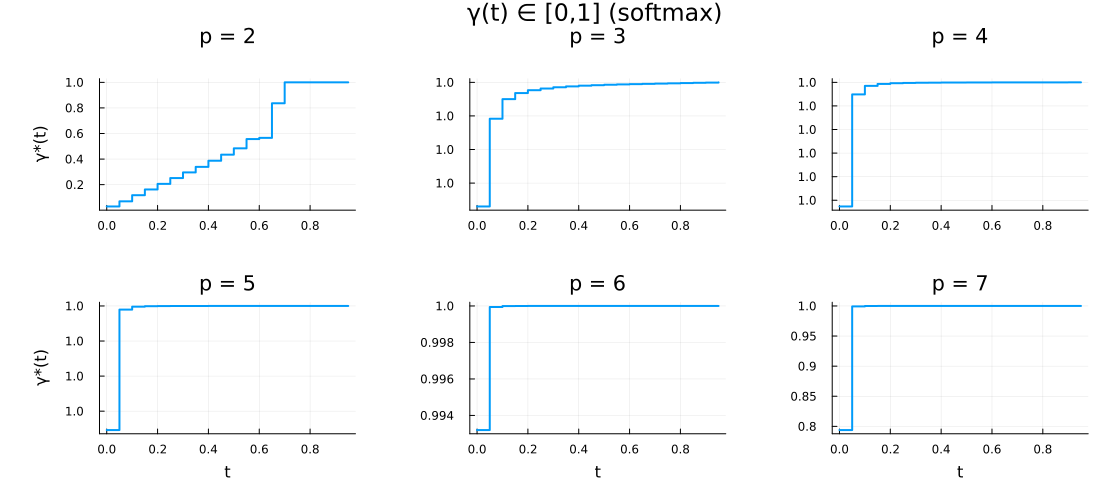

In [37]:
subplots = [
    plot(tgrid[1:end-1], g_stars_softmax[p],
        seriestype = :steppost, linewidth = 2,
        title = "p = $p",
        xlabel = p >= 5 ? "t" : "",
        ylabel = p in (2, 5) ? "γ*(t)" : "",
        legend = false,
        yformatter = x -> string(round(x, sigdigits=3)),
        left_margin = 12mm,
        top_margin = p <= 4 ? 8mm : 2mm,
        bottom_margin = p <= 4 ? 10mm : 8mm)
    for p in p_vals
]
plt_grid = plot(subplots..., layout = (2, 3), size = (1100, 500), plot_title = "γ(t) ∈ [0,1] (softmax)")

display(plt_grid)